In [14]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
PROJECT_ROOT = HERE.parent if HERE.name == "notebooks" else HERE
for path in (PROJECT_ROOT / "src", PROJECT_ROOT.parent):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, _ = tilt.load_tilt_tables(paths)
df_eddies = tilt.add_region_labels(df_eddies, grid)
df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=True)
df_eddies.head()

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,PV_grad_plan_theta,PV_grad_topo_mag,PV_grad_topo_theta,PV_grad_mag,PV_grad_theta,dtheta_PV_grad,dtheta_PV_grad_topo,dtheta_PV_grad_plan,Ro,topo_plan_ratio
0,1,1462,CE,152.716333,-38.866383,171,26,474.560686,127.605656,-0.000032,...,180.0,5.237207e-15,268.197739,6.587614e-15,232.618900,NaN,NaN,NaN,0.354182,0.311692
1,1,1463,CE,152.836206,-38.814279,173,28,482.821993,136.635735,-0.000041,...,180.0,4.803682e-15,302.931949,4.211944e-15,253.182819,NaN,NaN,NaN,0.443995,0.226497
2,1,1464,CE,152.905198,-38.816261,175,28,488.606048,138.480541,-0.000035,...,180.0,2.383894e-15,303.199762,3.215706e-15,218.339423,NaN,NaN,NaN,0.386802,-0.473493
3,1,1465,CE,152.719389,-38.902070,171,25,475.960098,123.953440,-0.000020,...,180.0,4.904626e-15,218.043527,8.269894e-15,201.437447,113.929675,130.535755,92.492228,0.217021,0.245968
4,1,1466,CE,152.753007,-38.935135,172,25,479.803789,121.483614,-0.000026,...,180.0,8.127877e-15,186.080405,1.195343e-14,184.130264,78.827876,80.778017,74.697612,0.285414,0.749766


In [34]:
df_eddies.columns

Index(['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'ic', 'jc', 'xc', 'yc', 'w',
       'Omega', 'q11', 'q12', 'q22', 'Rc', 'psi0', 'AR', 'R', 'Age', 'Date',
       'fname', 'TiltDis', 'TiltDir', 'Region', 'f', 'h', 'dhdx', 'dhdy',
       'beta', 'abs_vort', 'PV', 'PV_grad_plan_x', 'PV_grad_plan_y',
       'PV_grad_topo_x', 'PV_grad_topo_y', 'PV_grad_x', 'PV_grad_y',
       'PV_grad_plan_mag', 'PV_grad_plan_theta', 'PV_grad_topo_mag',
       'PV_grad_topo_theta', 'PV_grad_mag', 'PV_grad_theta', 'dtheta_PV_grad',
       'dtheta_PV_grad_topo', 'dtheta_PV_grad_plan', 'Ro', 'topo_plan_ratio'],
      dtype='object')

In [28]:
def vort_eddy(df, grid):
    df = df.copy()
    
    # Calculate total vorticity and PV
    
    # Normalised PV makes conservation particularly easy to see
    df['PV_norm'] = df['PV'] / df['PV'].iloc[0]
    
    fig = plt.figure(figsize=(11, 8), constrained_layout=True)
    gs = fig.add_gridspec(
        4, 2,
        width_ratios=[2, 1.3]
    )
    
    axs = [fig.add_subplot(gs[i, 0]) for i in range(4)]
    ax_traj = fig.add_subplot(gs[:, 1])
    
    # --------------------------------------------------
    # Time series
    # --------------------------------------------------
    
    # Depth
    axs[0].plot(df.Day, df.h, 'o-', ms=3)
    axs[0].set_ylabel(r'$h$ (m)')
    axs[0].set_title('Eddy PV evolution')
    
    # Planetary + relative vorticity
    axs[1].plot(df.Day, df.f, label=r'$f$')
    axs[1].plot(df.Day, df.w, label=r'$\omega$')
    axs[1].plot(df.Day, df.abs_vort, label=r'$\omega + f$')
    axs[1].set_ylabel(r'Vorticity (s$^{-1}$)')
    axs[1].legend(frameon=False)
    
    # PV
    axs[2].plot(df.Day, df.PV, 'o-', ms=3)
    axs[2].axhline(
        df.PV.iloc[0],
        ls='--',
        color='k',
        lw=1,
        label='Initial PV'
    )
    axs[2].set_ylabel(r'$q=(\omega+f)/h$')
    axs[2].legend(frameon=False)
    
    # Normalised PV
    axs[3].plot(df.Day, df.PV_norm, 'o-', ms=3)
    axs[3].axhline(1, ls='--', color='k', lw=1)
    axs[3].set_ylabel(r'$q/q_0$')
    axs[3].set_xlabel('Day')
    
    # Same x range for all time series
    for ax in axs:
        ax.grid(alpha=0.2)
    
    # --------------------------------------------------
    # Eddy trajectory
    # --------------------------------------------------
    
    sc = ax_traj.scatter(
        df.lon,
        df.lat,
        c=df.Day,
        cmap='viridis',
        s=30,
        zorder=3
    )
    
    ax_traj.plot(
        df.lon,
        df.lat,
        color='0.5',
        lw=1,
        zorder=2
    )
    
    # Mark start/end
    ax_traj.scatter(
        df.lon.iloc[0], df.lat.iloc[0],
        marker='o', s=100,
        facecolor='none', edgecolor='k',
        label='Start'
    )
    
    ax_traj.scatter(
        df.lon.iloc[-1], df.lat.iloc[-1],
        marker='x', s=100,
        color='k',
        label='End'
    )

    xlim, ylim = ax_traj.get_xlim(), ax_traj.get_ylim()
    ax_traj.contourf(grid.lon_rho, grid.lat_rho,
                     np.where(grid.mask_rho, grid.h, np.nan),
                     cmap='Grays_r', zorder=-1)
    ax_traj.set_xlim(xlim); ax_traj.set_ylim(ylim)
    
    ax_traj.set_xlabel('Longitude')
    ax_traj.set_ylabel('Latitude')
    ax_traj.set_title('Eddy trajectory')
    ax_traj.legend(frameon=False)
    
    cbar = fig.colorbar(sc, ax=ax_traj, pad=0.02)
    cbar.set_label('Day')
    
    plt.show()
    
    pv_change = 100 * (df.PV.iloc[-1] - df.PV.iloc[0]) / abs(df.PV.iloc[0])
    
    pv_cv = 100 * df.PV.std() / abs(df.PV.mean())
    
    print(f'PV change over lifetime: {pv_change:.2f}%')
    print(f'PV coefficient of variation: {pv_cv:.2f}%')

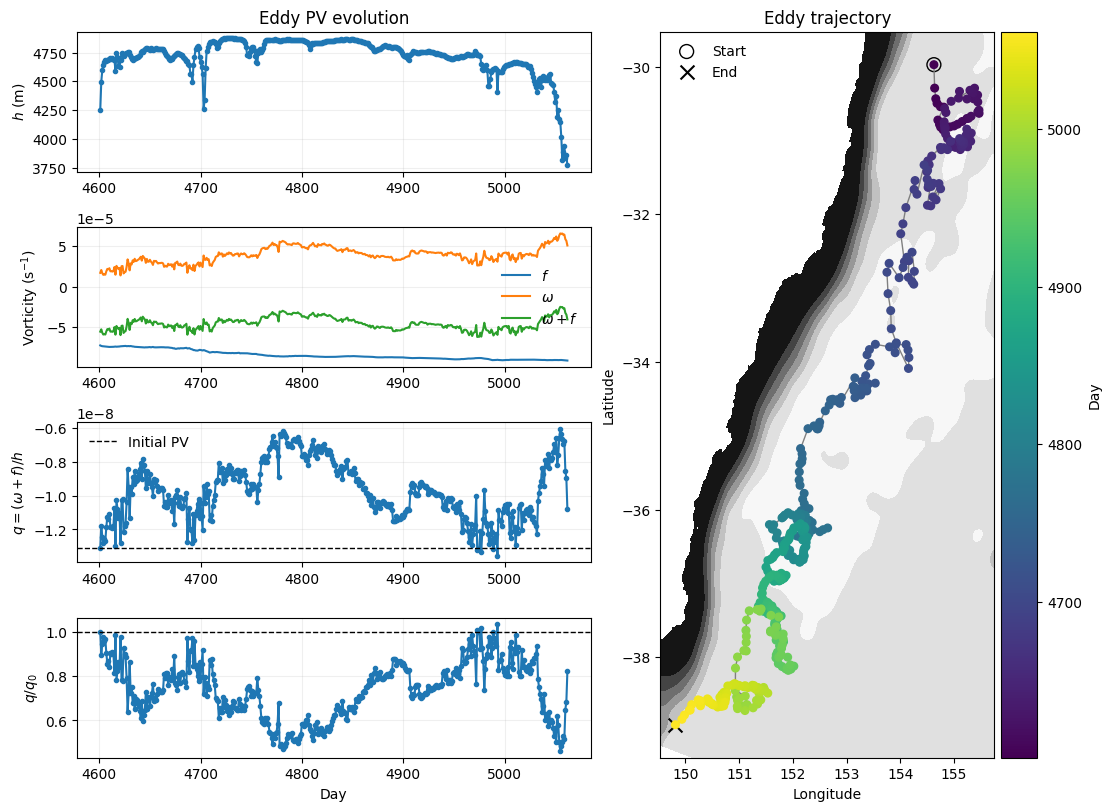

PV change over lifetime: 17.83%
PV coefficient of variation: 17.36%


In [29]:
old_eddy = [int(df_eddies[df_eddies.Age==df_eddies.Age.max()].Eddy.iloc[0])]
df_old = df_eddies[df_eddies.Eddy==old_eddy[0]].copy()
# df_old = tilt.add_pv_gradient_terms(df_old, grid, core_mean=True)
vort_eddy(df_old.copy(), grid)


In [30]:
max_ratio = (
    df_eddies[df_eddies.Age > 100]
    .groupby('Eddy')['topo_plan_ratio']
    .mean()
    .sort_values(ascending=False)
)

max_ratio

Eddy
13      2.956140
37      2.830299
231     2.770185
369     2.703118
2297    2.664543
          ...   
1260   -0.587972
1619   -0.658786
2394   -0.676680
1616   -0.778056
324    -0.806522
Name: topo_plan_ratio, Length: 125, dtype: float64

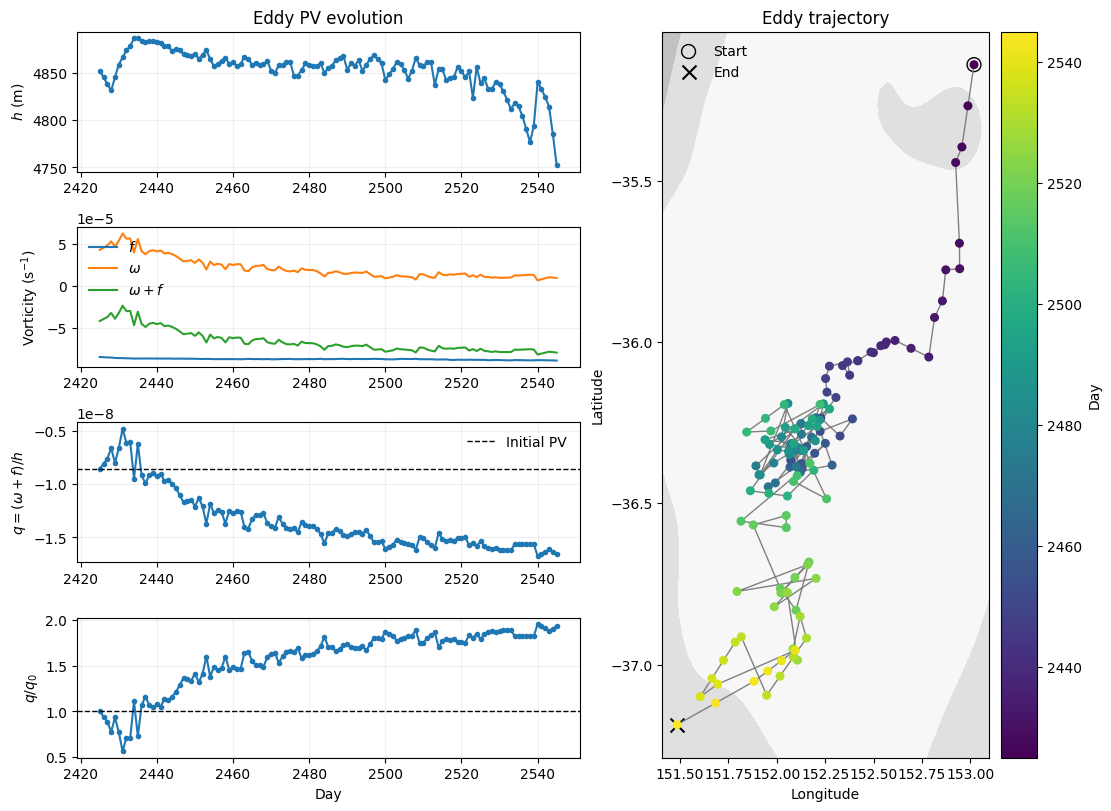

PV change over lifetime: -93.61%
PV coefficient of variation: 20.72%


In [31]:
vort_eddy(df_eddies[df_eddies.Eddy==324].copy(), grid)

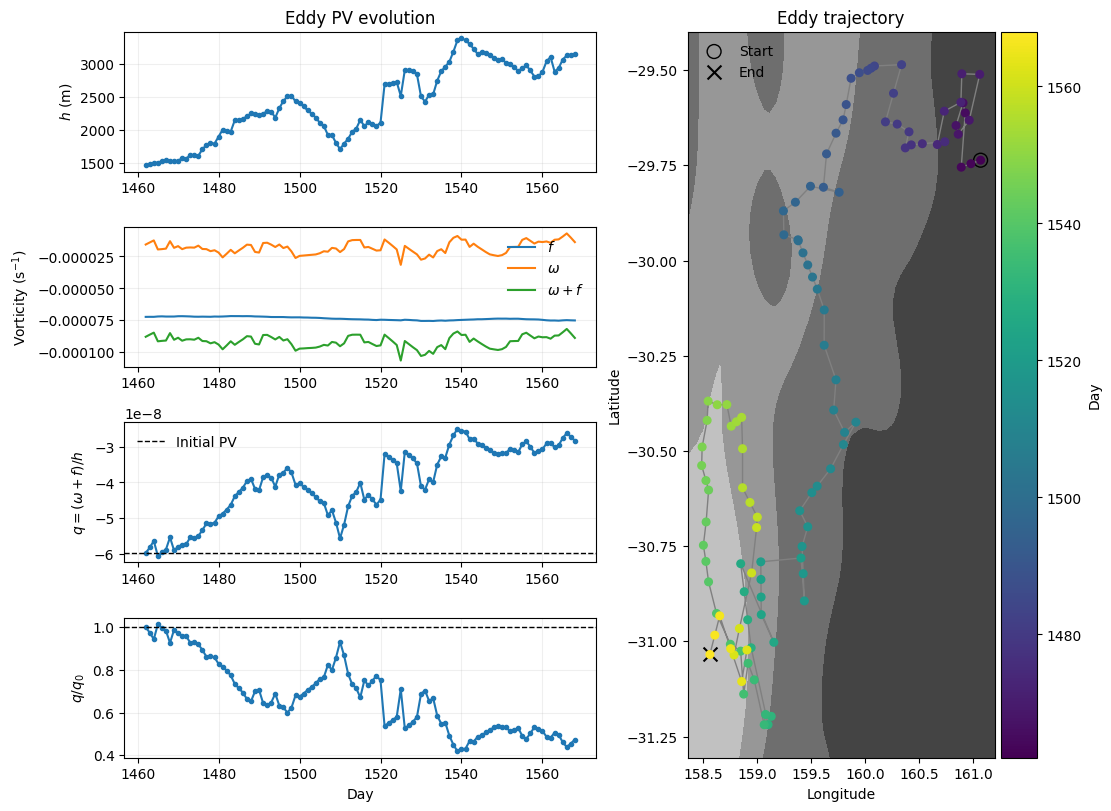

PV change over lifetime: 52.66%
PV coefficient of variation: 24.81%


In [32]:
vort_eddy(df_eddies[df_eddies.Eddy==13].copy(), grid)